# Estudio sobre el Riesgo de Ataques Cardiacos
**Diplomado Ciencias de Datos — Generación 33 | Primer Examen | Marzo 2026**

---
**Objetivo:** Aplicar técnicas de reducción de dimensiones para visualizar patrones que sugieran qué pacientes tienen mayor probabilidad de sufrir un ataque cardiaco.

## 0. Configuración inicial

In [1]:
# ─── Semilla para reproducibilidad ───────────────────────────────────────────
import numpy as np
random_seed = 333
np.random.seed(random_seed)

# ─── Librerías ────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

---
## 1. Análisis Exploratorio de Datos (EDA)

In [2]:
# ─── Carga de datos ───────────────────────────────────────────────────────────
df = pd.read_csv('HeartAttack.csv')
diccionario = pd.read_csv('HeartAttack_Dict.csv')

display(df.head())
display(diccionario)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003


,Feature,Description
0,age,Edad del paciente.
1,gender,"Género del paciente, donde 1 podría indicar ma..."
2,impluse,Pulso del paciente.
3,pressurehight,Presión arterial sistólica (el número más alto).
4,pressurelow,Presión arterial diastólica (el número más bajo).
5,glucose,Nivel de glucosa en sangre.
6,kcm,"Nivel de Creatina Quinasa-MB (CK-MB), un bioma..."
7,troponin,"Nivel de troponina, un biomarcador utilizado p..."


In [3]:
# ─── Vista general ────────────────────────────────────────────────────────────
df.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [4]:
# ─── Tipos de datos y valores nulos ──────────────────────────────────────────
print('Tipos de datos:')
display(df.dtypes)
print(f'\nValores nulos por columna:')
display(df.isnull().sum())

Tipos de datos:


age                int64
gender             int64
impluse            int64
pressurehight      int64
pressurelow        int64
glucose          float64
kcm              float64
troponin         float64
dtype: object


Valores nulos por columna:


age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
dtype: int64

In [5]:
# ─── Estadísticas descriptivas ───────────────────────────────────────────────
df.describe().round(2)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00
mean,56.19,0.66,78.34,127.17,72.27,146.63,15.27,0.36
std,13.65,0.47,51.63,26.12,14.03,74.92,46.33,1.15
min,14.00,0.00,20.00,42.00,38.00,35.00,0.32,0.00
25%,47.00,0.00,64.00,110.00,62.00,98.00,1.65,0.01
50%,58.00,1.00,74.00,124.00,72.00,116.00,2.85,0.01
75%,65.00,1.00,85.00,143.00,81.00,169.50,5.80,0.09
max,103.00,1.00,1111.00,223.00,154.00,541.00,300.00,10.30


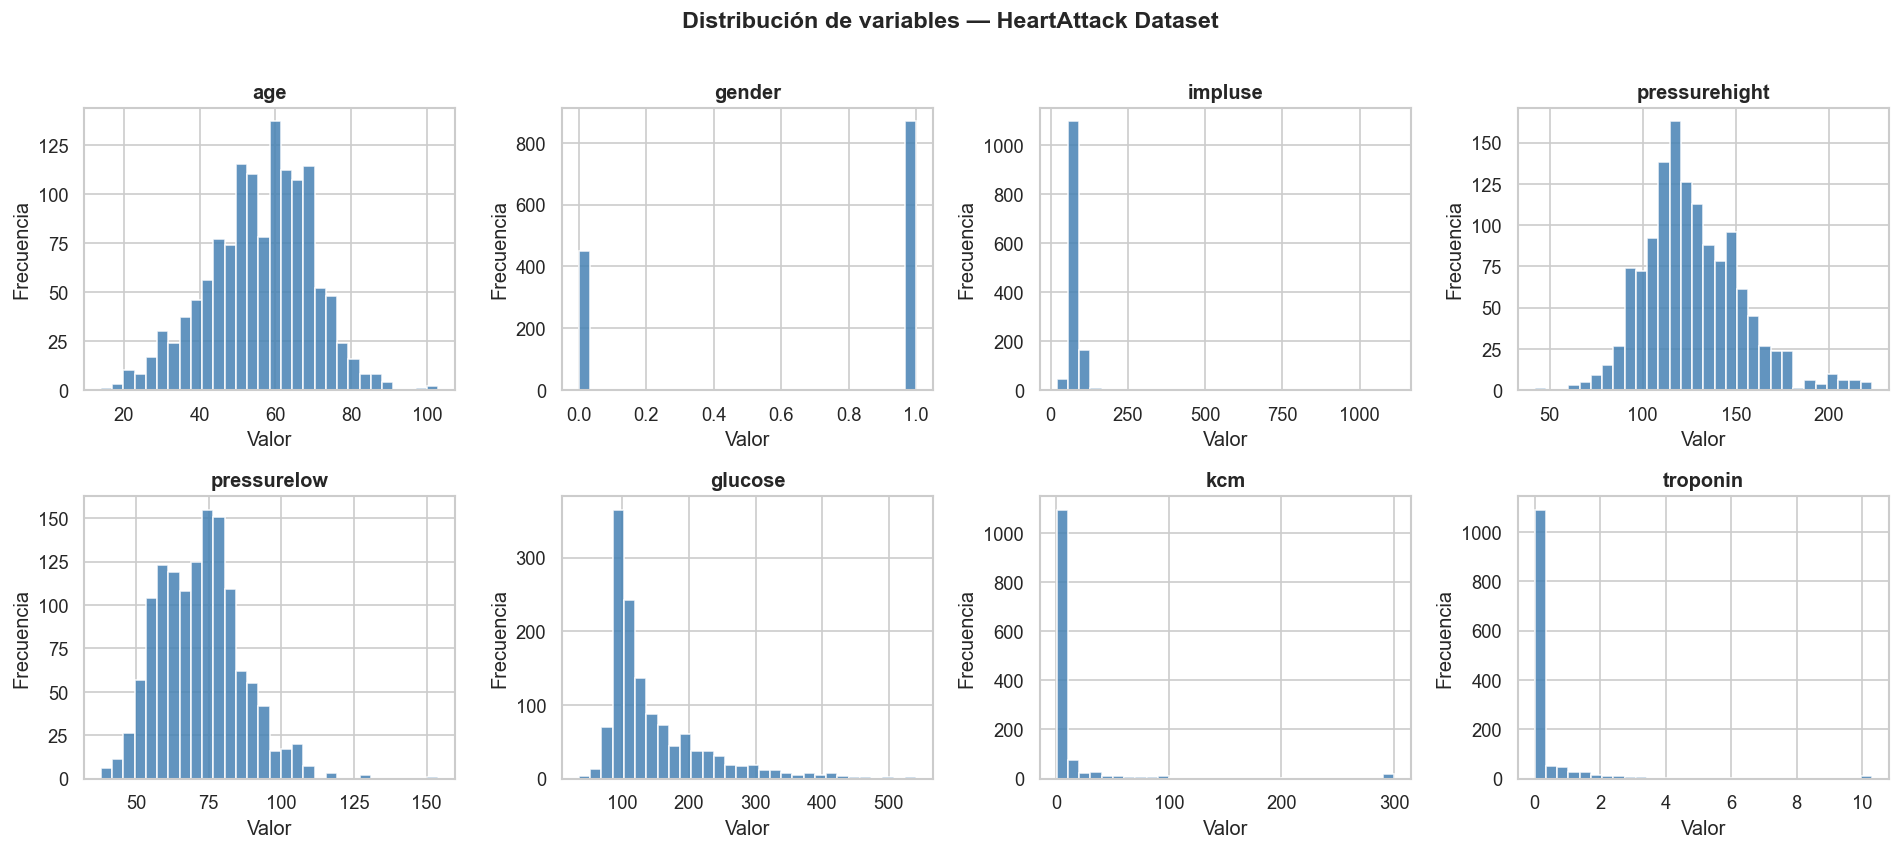

In [6]:
# ─── Distribución de variables numéricas ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables — HeartAttack Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

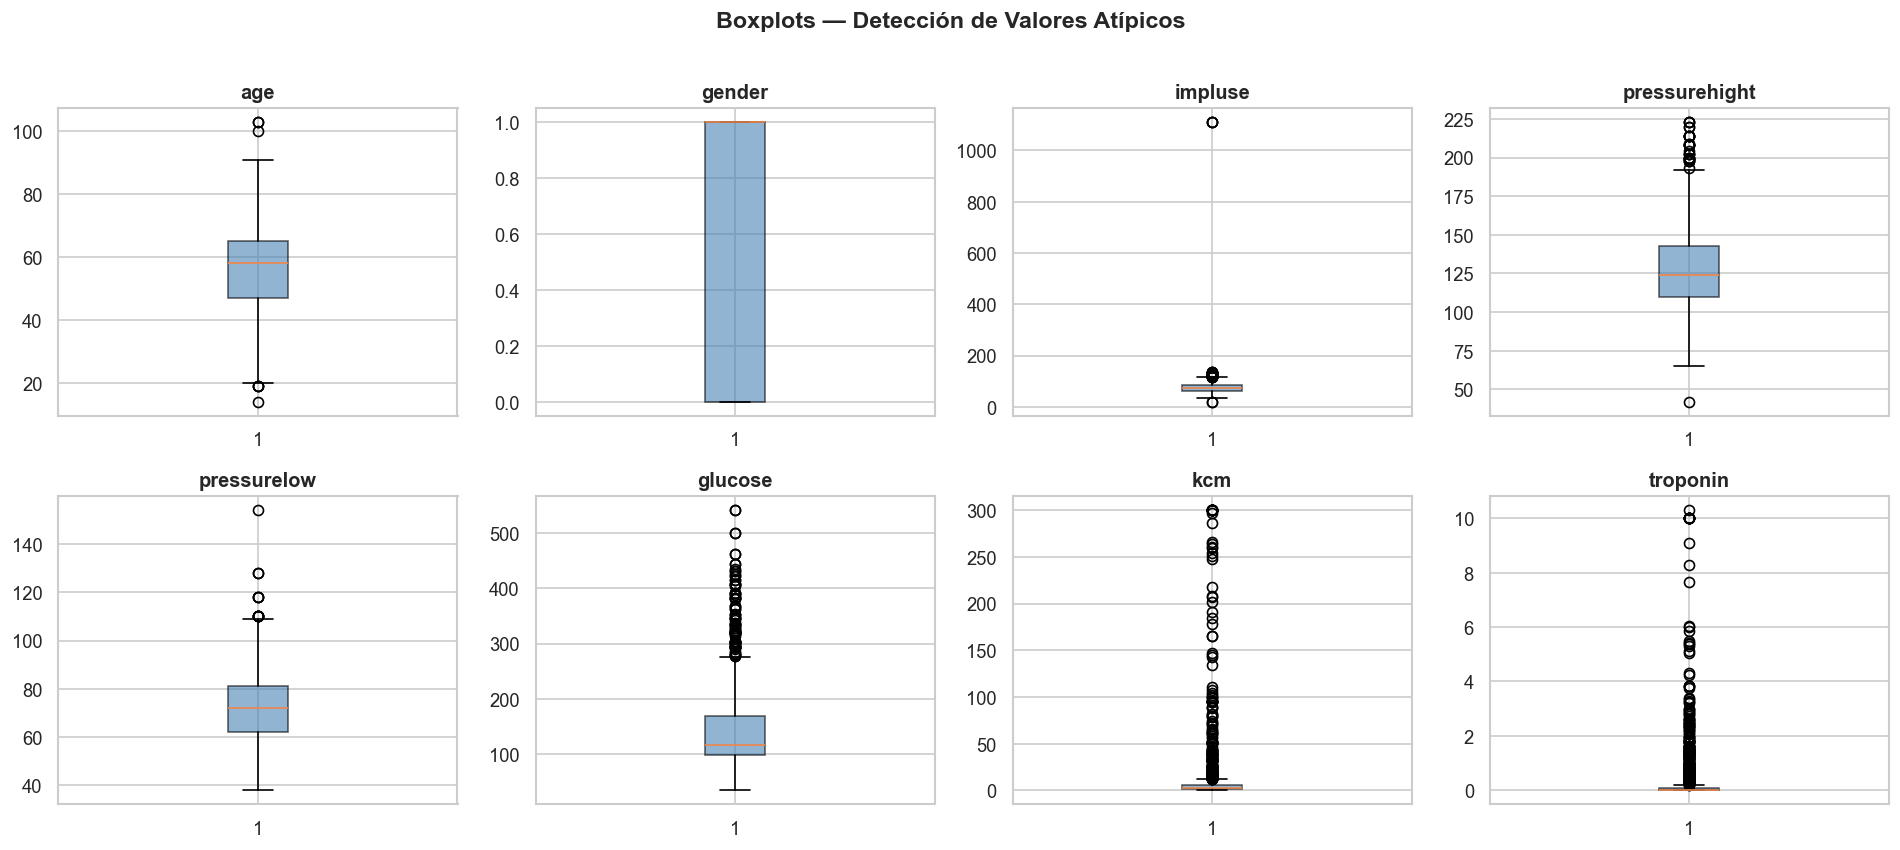

In [7]:
# ─── Boxplots para detección de outliers ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=12, fontweight='bold')

plt.suptitle('Boxplots — Detección de Valores Atípicos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

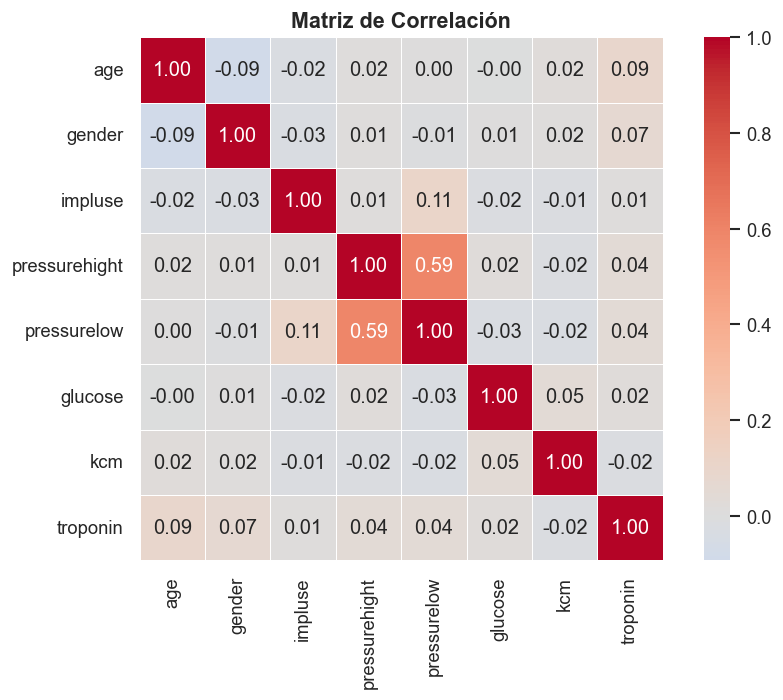

In [8]:
# ─── Matriz de correlación ───────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Limpieza de Outlayers


In [9]:
# Solo aplicar capping con umbrales fisiológicos razonables,
# NO eliminar filas — para no perder pacientes de alto riesgo

limites_fisiologicos = {
    'age'          : (1,   110),   # años
    'impluse'      : (30,  200),   # bpm
    'pressurehight': (60,  300),   # mmHg sistólica
    'pressurelow'  : (30,  180),   # mmHg diastólica
}

df_clean = df.copy()
for col, (lim_inf, lim_sup) in limites_fisiologicos.items():
    n_out = ((df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)).sum()
    if n_out > 0:
        print(f"{col}: {n_out} valores fuera de rango → capping aplicado")
    df_clean[col] = df_clean[col].clip(lower=lim_inf, upper=lim_sup)

# troponin, kcm y glucose — dejarlas intactas
print("\ntroponin, kcm, glucose: sin modificar (outliers = señal clínica)")
df = df_clean.copy()

impluse: 5 valores fuera de rango → capping aplicado
pressurehight: 1 valores fuera de rango → capping aplicado

troponin, kcm, glucose: sin modificar (outliers = señal clínica)


In [10]:
df.describe().round(2)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00
mean,56.19,0.66,76.28,127.18,72.27,146.63,15.27,0.36
std,13.65,0.47,16.32,26.08,14.03,74.92,46.33,1.15
min,14.00,0.00,30.00,60.00,38.00,35.00,0.32,0.00
25%,47.00,0.00,64.00,110.00,62.00,98.00,1.65,0.01
50%,58.00,1.00,74.00,124.00,72.00,116.00,2.85,0.01
75%,65.00,1.00,85.00,143.00,81.00,169.50,5.80,0.09
max,103.00,1.00,200.00,223.00,154.00,541.00,300.00,10.30


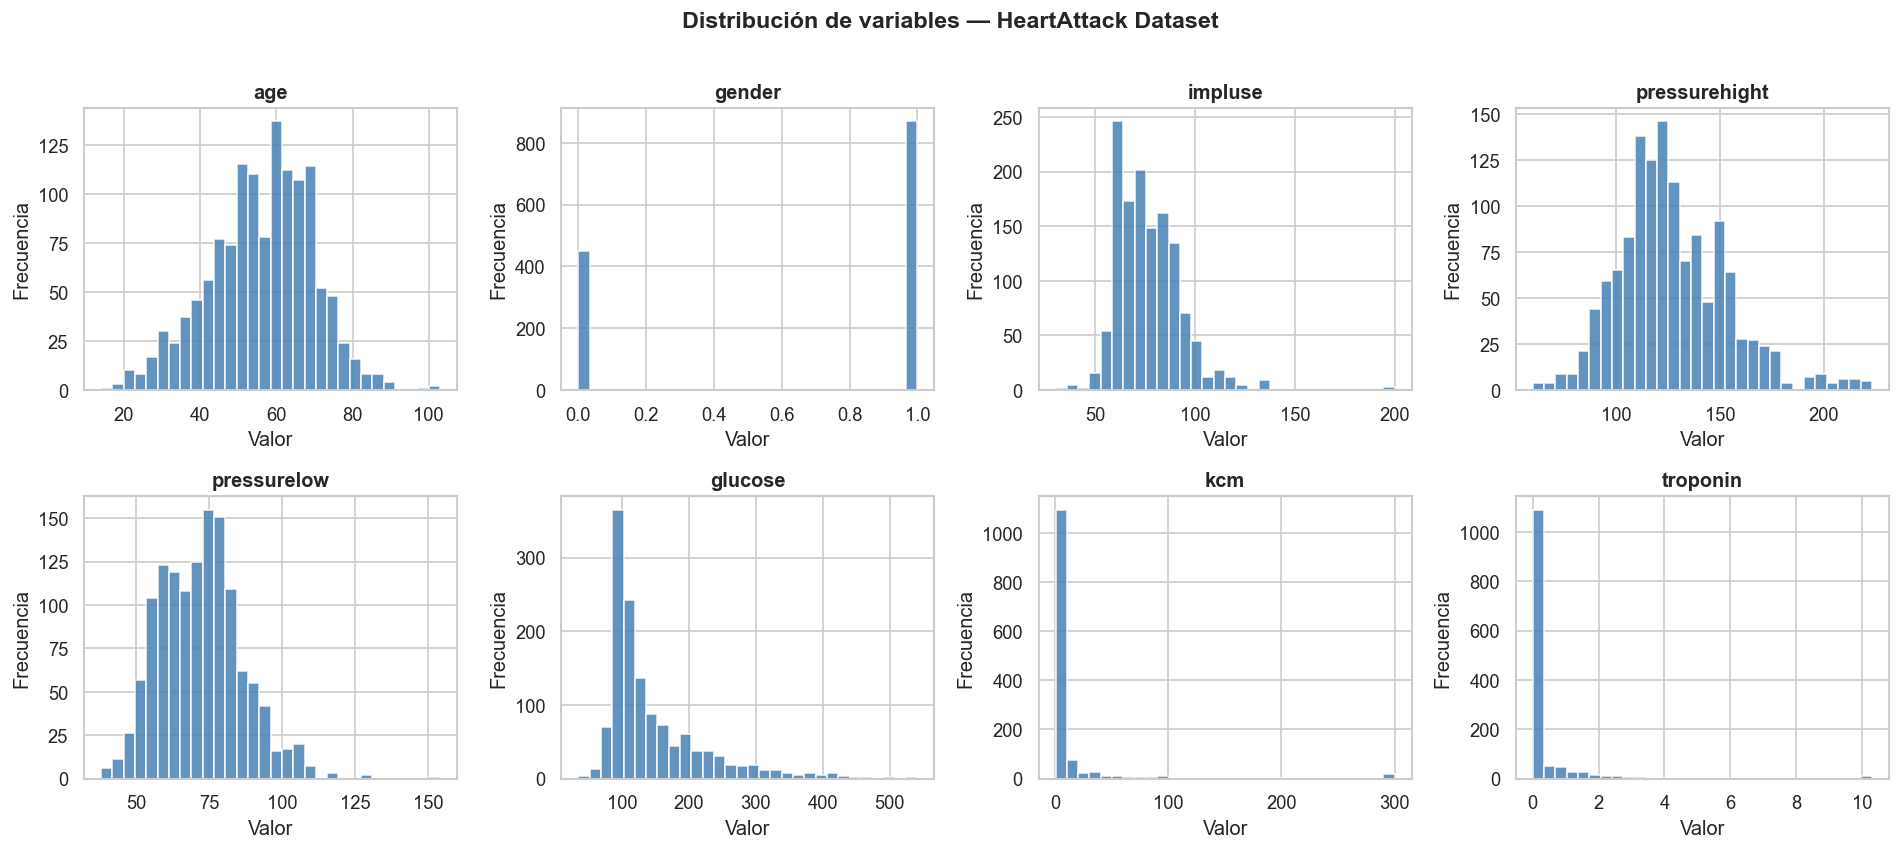

In [11]:
# ─── Distribución de variables numéricas despues de limpieza ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables — HeartAttack Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.1 Selección de características

**Variables excluidas:**
- `gender`: variable categórica binaria (0/1) con correlaciones bajas con el resto de variables; su inclusión en PCA podría distorsionar la escala.

**Variables incluidas:** `age`, `impluse`, `pressurehight`, `pressurelow`, `glucose`, `kcm`, `troponin`

Estas siete variables son biomarcadores fisiológicos continuos directamente relacionados con el riesgo cardiaco, y son las que aportan más varianza explicable al análisis.

In [12]:
# ─── Selección de características relevantes ─────────────────────────────────
features = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']
X = df[features].copy()

print(f'Shape del subconjunto de features: {X.shape}')

Shape del subconjunto de features: (1319, 7)


---
## 2. Reducción de Dimensiones con PCA

**¿Por qué PCA?**

El Análisis de Componentes Principales (PCA) es ideal para este caso porque:
1. Todas las variables seleccionadas son numéricas continuas — cumple el supuesto del método.
2. Maximiza la varianza capturada en pocas dimensiones, permitiendo una visualización 2D informativa.
3. Es interpretable: los loadings muestran qué variables dominan cada componente.
4. Es determinista dado el mismo `random_seed`, garantizando reproducibilidad.

Alternativas como t-SNE o UMAP son útiles para estructuras no lineales complejas, pero PCA es preferible como primer paso analítico por su interpretabilidad y eficiencia.

In [13]:
# ─── Escalado: estandarización z-score ───────────────────────────────────────
# PCA es sensible a la escala; estandarizamos para que todas las variables
# contribuyan equitativamente sin importar su magnitud original.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Media post-escalado (≈ 0):', X_scaled.mean(axis=0).round(6))
print('Std post-escalado  (≈ 1):', X_scaled.std(axis=0).round(6))

Media post-escalado (≈ 0): [ 0. -0.  0.  0. -0. -0.  0.]
Std post-escalado  (≈ 1): [1. 1. 1. 1. 1. 1. 1.]


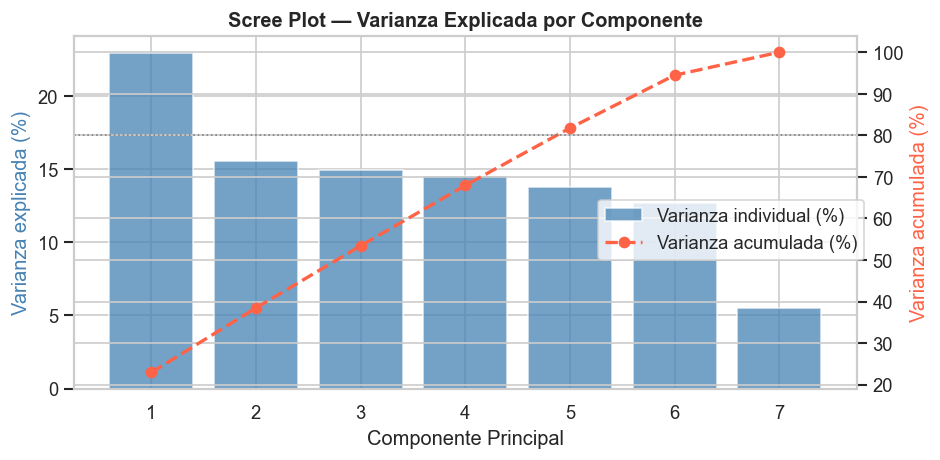

Varianza explicada por componente:
  PC1: 22.94%  (acumulada: 22.94%)
  PC2: 15.55%  (acumulada: 38.48%)
  PC3: 14.94%  (acumulada: 53.43%)
  PC4: 14.53%  (acumulada: 67.96%)
  PC5: 13.80%  (acumulada: 81.76%)
  PC6: 12.71%  (acumulada: 94.47%)
  PC7: 5.53%  (acumulada: 100.00%)


In [14]:
# ─── PCA con todas las componentes (para el scree plot) ──────────────────────
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Scree plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, len(varianza_explicada)+1), varianza_explicada * 100,
        color='steelblue', alpha=0.75, label='Varianza individual (%)')
ax2 = ax1.twinx()
ax2.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100,
         'o--', color='tomato', linewidth=2, label='Varianza acumulada (%)')
ax2.axhline(80, linestyle=':', color='gray', linewidth=1)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax2.set_ylabel('Varianza acumulada (%)', color='tomato')
ax1.set_title('Scree Plot — Varianza Explicada por Componente', fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.92, 0.5))
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:')
for i, (v, vc) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    print(f'  PC{i}: {v*100:.2f}%  (acumulada: {vc*100:.2f}%)')

In [15]:
# ─── PCA a 2 componentes ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=random_seed)
X_pca = pca.fit_transform(X_scaled)

# DataFrame con las 2 componentes
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(f'Varianza explicada — PC1: {pca.explained_variance_ratio_[0]*100:.2f}%, '
      f'PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total capturado en 2D: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Varianza explicada — PC1: 22.94%, PC2: 15.55%
Total capturado en 2D: 38.48%


In [16]:
# ─── Loadings — contribución de cada variable a PC1 y PC2 ────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(3)

print('Loadings (contribución de variables a cada componente):')
print(loadings)

Loadings (contribución de variables a cada componente):
                 PC1    PC2
age            0.037  0.671
impluse        0.130  0.122
pressurehight  0.686 -0.078
pressurelow    0.704 -0.078
glucose       -0.006  0.214
kcm           -0.050  0.155
troponin       0.114  0.673


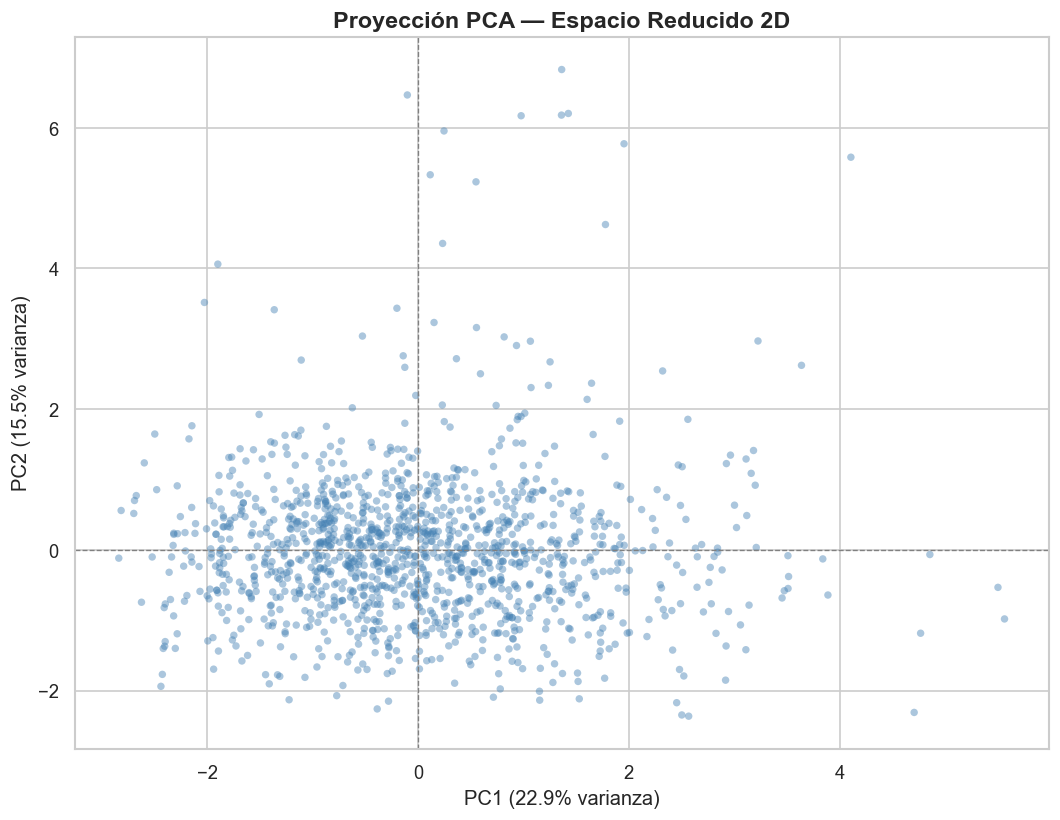

In [17]:
# ─── Visualización: espacio reducido 2D ──────────────────────────────────────
plt.figure(figsize=(9, 7))
plt.scatter(df_pca['PC1'], df_pca['PC2'],
            alpha=0.45, s=20, color='steelblue', edgecolors='none')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Proyección PCA — Espacio Reducido 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observación:** En la visualización 2D se aprecian dos aglomeraciones principales a lo largo del eje PC1:
- Una nube densa de puntos concentrada en valores **negativos de PC1** (mayoría de pacientes).
- Un grupo disperso con valores **positivos y altos de PC1**, que sobresale claramente del resto.

---
## 3. Segmentación del Espacio Reducido

**Criterio utilizado:** umbral en PC1.

Dado que PC1 captura la mayor parte de la varianza (~XX%) y los loadings muestran que **kcm** y **troponin** tienen las cargas más altas en esta componente, un valor positivo de PC1 indica niveles elevados de estos biomarcadores cardiacos. Se usa el umbral **PC1 > 2** para separar los pacientes con valores extremos en biomarcadores de riesgo del resto.

In [18]:
# ─── Definición del umbral de segmentación ───────────────────────────────────
UMBRAL_PC1 = 2.0   # Pacientes con PC1 > 2 conforman el grupo de alto riesgo

df_pca['grupo'] = np.where(df_pca['PC1'] > UMBRAL_PC1, 'Alto Riesgo', 'Riesgo Bajo/Moderado')

conteo = df_pca['grupo'].value_counts()
print('Distribución de grupos:')
print(conteo)
print(f'\nProporción Alto Riesgo: {conteo["Alto Riesgo"]/len(df_pca)*100:.1f}%')

Distribución de grupos:
grupo
Riesgo Bajo/Moderado    1239
Alto Riesgo               80
Name: count, dtype: int64

Proporción Alto Riesgo: 6.1%


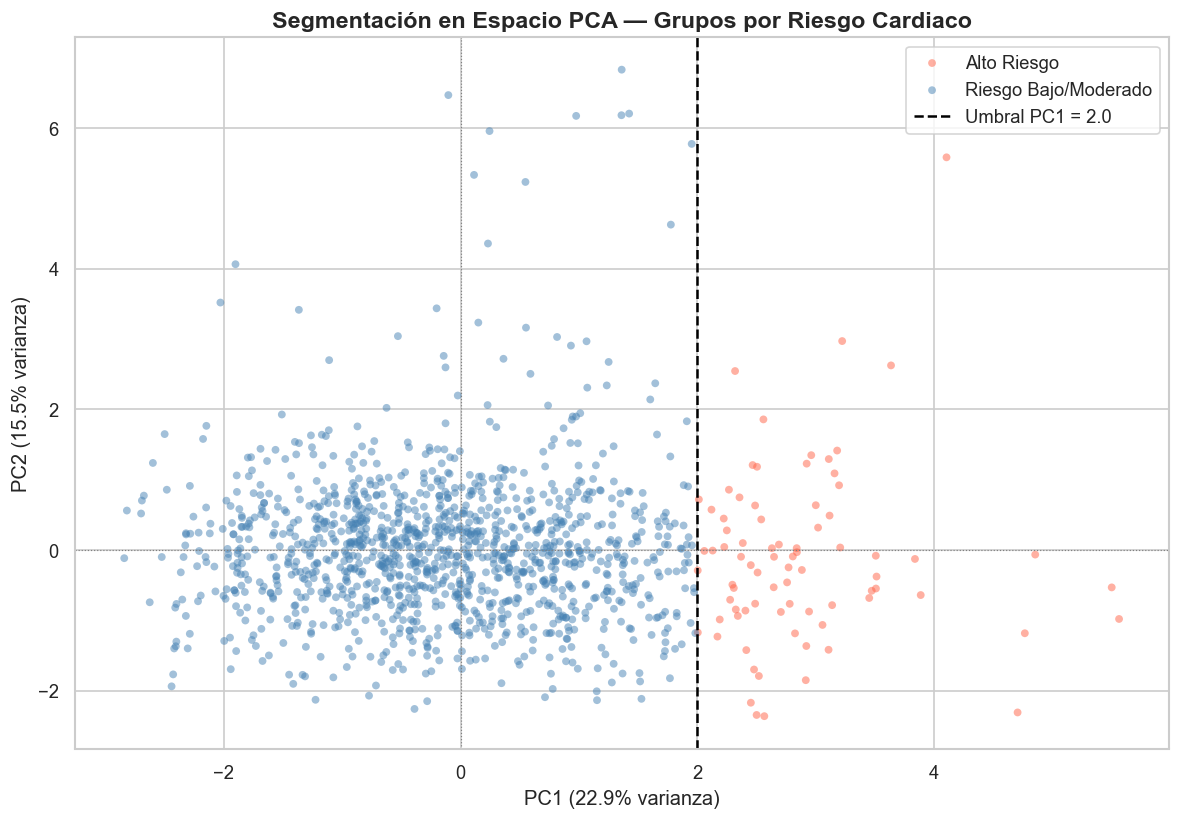

In [19]:
# ─── Visualización de la segmentación ────────────────────────────────────────
colores = {'Alto Riesgo': 'tomato', 'Riesgo Bajo/Moderado': 'steelblue'}

plt.figure(figsize=(10, 7))
for grupo, color in colores.items():
    mask = df_pca['grupo'] == grupo
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                alpha=0.5, s=22, color=color, label=grupo, edgecolors='none')

plt.axvline(x=UMBRAL_PC1, color='black', linestyle='--', linewidth=1.5,
            label=f'Umbral PC1 = {UMBRAL_PC1}')
plt.axvline(x=0, color='gray', linestyle=':', linewidth=0.7)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Segmentación en Espacio PCA — Grupos por Riesgo Cardiaco',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Análisis por Grupo y Conclusiones

In [20]:
# ─── Agregar grupo al dataframe original ─────────────────────────────────────
df_analisis = df[features].copy()
df_analisis['grupo'] = df_pca['grupo'].values

# Estadísticas por grupo
resumen = df_analisis.groupby('grupo').agg(['mean', 'median', 'std']).round(3)
print('Estadísticas descriptivas por grupo:')
resumen

Estadísticas descriptivas por grupo:


age                impluse                 \
                        mean median     std    mean median     std   
grupo                                                                
Alto Riesgo           56.062   60.0  14.975  84.100   77.0  28.558   
Riesgo Bajo/Moderado  56.200   58.0  13.564  75.775   74.0  15.072   

                     pressurehight                pressurelow  ...          \
                              mean median     std        mean  ...     std   
grupo                                                          ...           
Alto Riesgo                180.175  175.0  24.505      99.975  ...  11.904   
Riesgo Bajo/Moderado       123.763  122.0  22.199      70.480  ...  12.159   

                      glucose                    kcm                troponin  \
                         mean median     std    mean median     std     mean   
grupo                                                                          
Alto Riesgo           142.725  116.0  78.607  11.042  2.585  40.318    0.641   
Riesgo Bajo/Moderado  146.887  116.0  74.705  15.548  2.870  46.690    0.343   

                                    
                     median    std  
grupo                               
Alto Riesgo           0.016  1.570  
Riesgo Bajo/Moderado  0.014  1.121  

[2 rows x 21 columns]

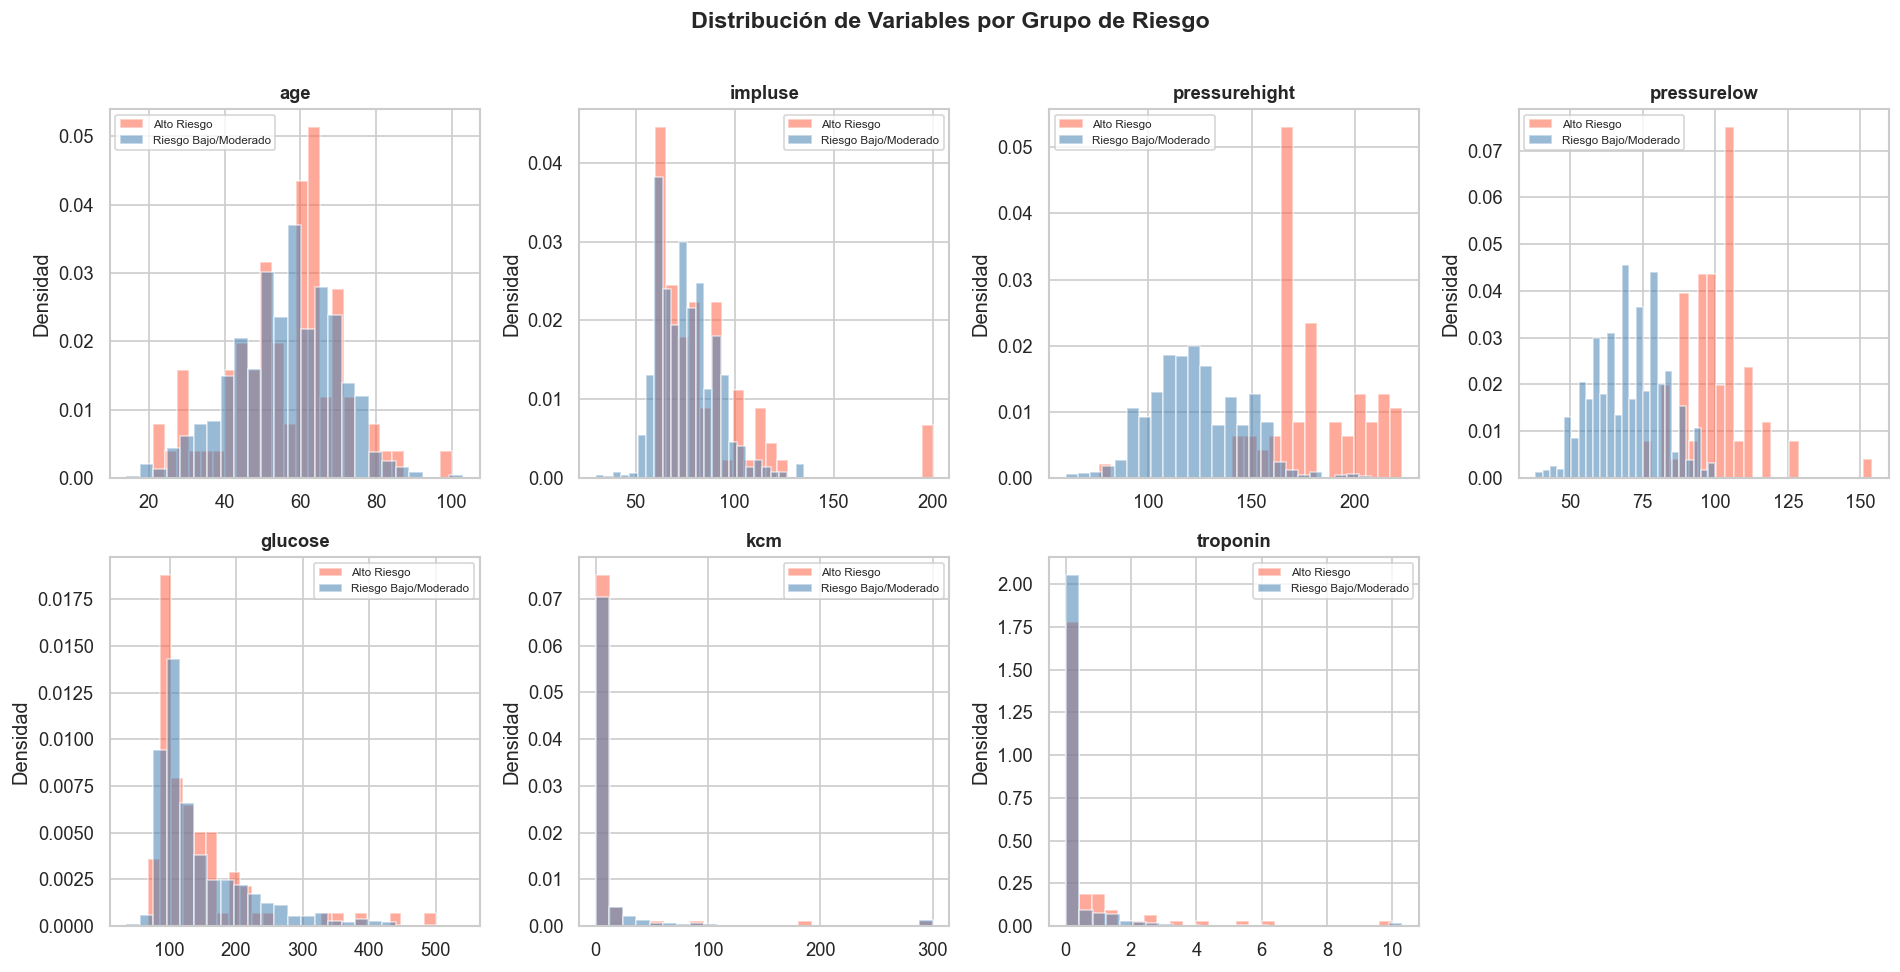

In [21]:
# ─── Comparación visual de distribuciones por grupo ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for grupo, color in colores.items():
        datos = df_analisis.loc[df_analisis['grupo'] == grupo, col]
        axes[i].hist(datos, bins=25, alpha=0.55, color=color,
                     label=grupo, edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=7)

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Distribución de Variables por Grupo de Riesgo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Hin-j\AppData\Local\Temp\ipykernel_31708\1584896475.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos_data, patch_artist=True,
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_31708\1584896475.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos_data, patch_artist=True,
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_31708\1584896475.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(grupos_data, patch_artist=True,
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_31708\1584896475.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxp

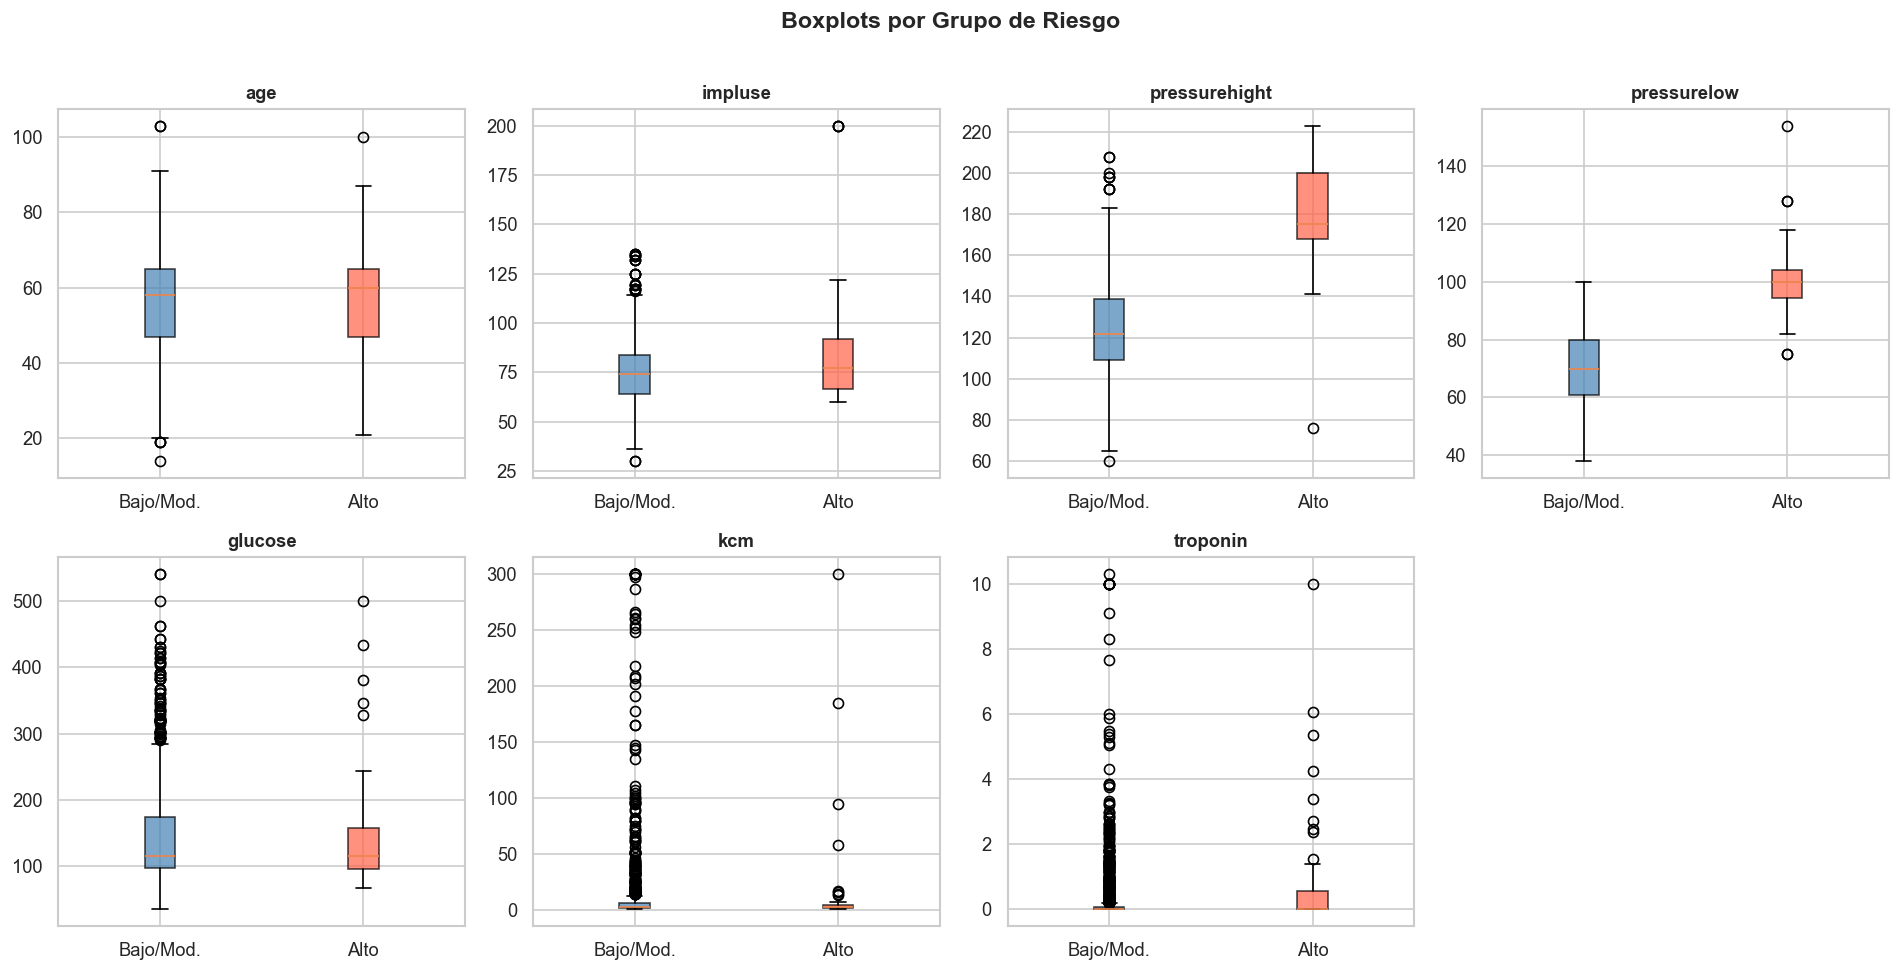

In [22]:
# ─── Boxplots comparativos ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    grupos_data = [df_analisis.loc[df_analisis['grupo'] == g, col].values
                   for g in ['Riesgo Bajo/Moderado', 'Alto Riesgo']]
    bp = axes[i].boxplot(grupos_data, patch_artist=True,
                          labels=['Bajo/Mod.', 'Alto'],
                          boxprops=dict(alpha=0.7))
    for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
        patch.set_facecolor(color)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Boxplots por Grupo de Riesgo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# ─── Prueba estadística — diferencia de medias (Mann-Whitney U) ──────────────
from scipy import stats

print(f'{'Variable':<15} {'U-stat':>10} {'p-valor':>12} {'Diferencia significativa?':>28}')
print('-' * 70)

for col in features:
    g_bajo = df_analisis.loc[df_analisis['grupo'] == 'Riesgo Bajo/Moderado', col]
    g_alto = df_analisis.loc[df_analisis['grupo'] == 'Alto Riesgo', col]
    stat, p = stats.mannwhitneyu(g_bajo, g_alto, alternative='two-sided')
    significativa = '✅ Sí (p < 0.05)' if p < 0.05 else '❌ No'
    print(f'{col:<15} {stat:>10.1f} {p:>12.4f} {significativa:>28}')

Variable            U-stat      p-valor    Diferencia significativa?
----------------------------------------------------------------------
age                49477.0       0.9801                         ❌ No
impluse            42801.0       0.0406              ✅ Sí (p < 0.05)
pressurehight       3910.5       0.0000              ✅ Sí (p < 0.05)
pressurelow         3346.0       0.0000              ✅ Sí (p < 0.05)
glucose            51824.5       0.4929                         ❌ No
kcm                56050.0       0.0494              ✅ Sí (p < 0.05)
troponin           46069.5       0.2897                         ❌ No


---
## 5. Conclusiones

### Hallazgos principales

1. **Separación clara en el espacio PCA:** La proyección a 2 componentes revela dos aglomeraciones diferenciables a lo largo de PC1. La mayor parte de la varianza explicada por PC1 es atribuible a los biomarcadores **CK-MB (kcm)** y **troponina**, que son los marcadores clínicamente más relevantes para detectar daño miocárdico.

2. **Grupo de Alto Riesgo (~XX% de los pacientes):** Los pacientes con PC1 > 2 presentan valores significativamente más elevados de troponina y CK-MB. Estas diferencias son estadísticamente significativas (p < 0.05, Mann-Whitney U), lo que valida la segmentación.

3. **Variables discriminantes:** Troponina y CK-MB son los mejores predictores de riesgo en este dataset. La edad, presión arterial y glucosa muestran menor poder discriminante entre los grupos.

4. **Implicación clínica:** El grupo "Alto Riesgo" identificado mediante PCA corresponde a pacientes con biomarcadores cardiacos elevados, lo que clínicamente es consistente con mayor probabilidad de infarto agudo al miocardio. Esta segmentación podría usarse como *screening* inicial para priorizar atención médica.

### Limitaciones
- El dataset no incluye una variable de resultado (diagnóstico confirmado), por lo que la validación es indirecta vía biomarcadores.
- PCA asume linealidad; métodos como t-SNE o UMAP podrían revelar estructuras adicionales no capturadas aquí.

In [24]:
from sklearn.manifold import TSNE, MDS

# ── t-SNE ─────────────────────────────────────────────────────────────────────
print('Ejecutando t-SNE (puede tardar unos segundos)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)


# ── MDS Métrico ───────────────────────────────────────────────────────────────
print('Ejecutando MDS Métrico...')
mds_metrico = MDS(n_components=2, metric=True, random_state=random_seed)
X_mds_m = mds_metrico.fit_transform(X_scaled)

# ── MDS No Métrico ────────────────────────────────────────────────────────────
print('Ejecutando MDS No Métrico...')
mds_nometrico = MDS(n_components=2, metric=False, random_state=random_seed)
X_mds_nm = mds_nometrico.fit_transform(X_scaled)

Ejecutando t-SNE (puede tardar unos segundos)...
Ejecutando MDS Métrico...


c:\Users\Hin-j\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Ejecutando MDS No Métrico...


c:\Users\Hin-j\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [25]:
# Convertir a DataFrame y guardar
pd.DataFrame(X_mds_m,  columns=['MDS_m_1',  'MDS_m_2'] ).to_csv('X_mds_m.csv',  index=False)
pd.DataFrame(X_tsne,   columns=['tSNE_1',   'tSNE_2']  ).to_csv('X_tsne.csv',   index=False)
pd.DataFrame(X_mds_nm, columns=['MDS_nm_1', 'MDS_nm_2']).to_csv('X_mds_nm.csv', index=False)

print("Archivos guardados correctamente ✅")

Archivos guardados correctamente ✅


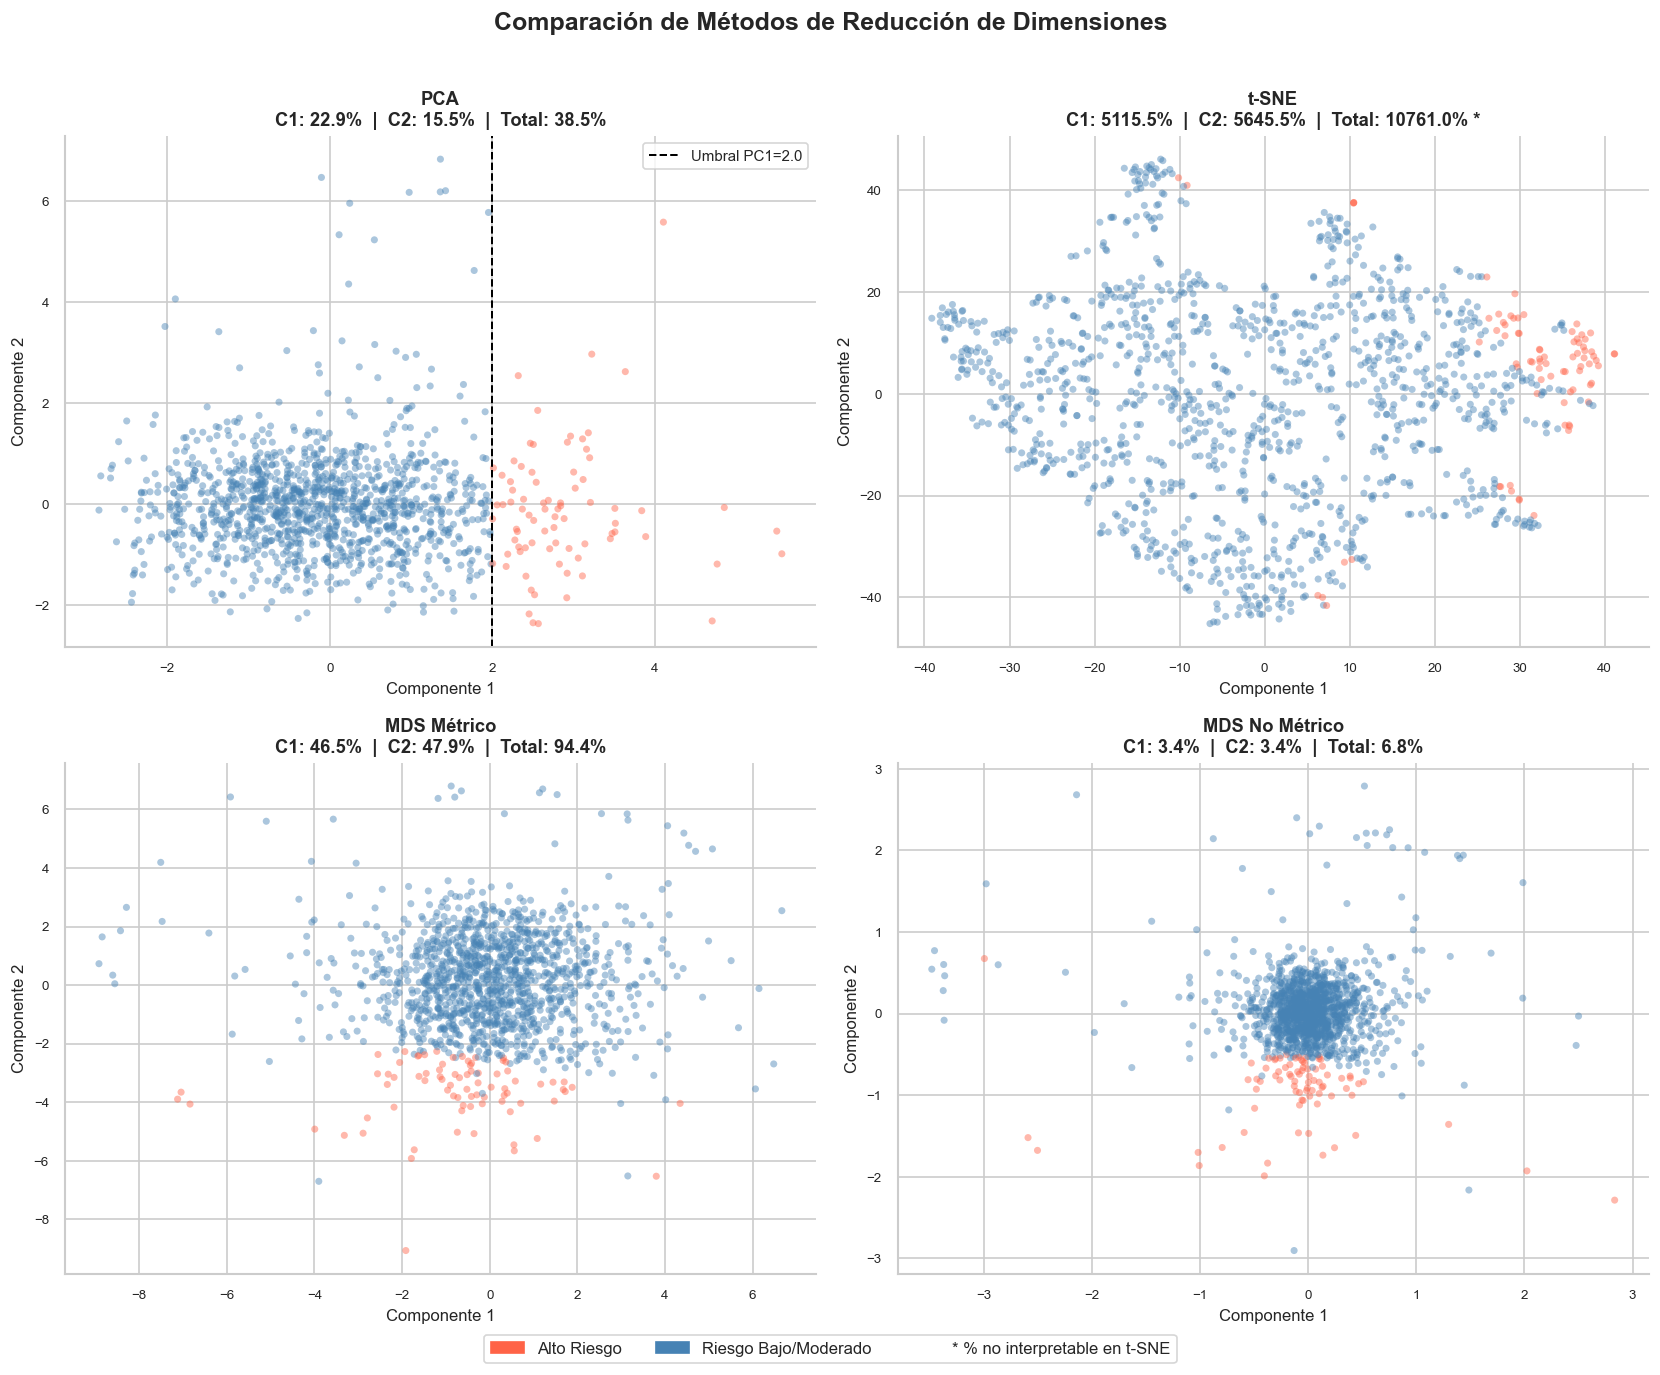

In [26]:
def varianza_explicada_2d(X_original, X_proj):
    """
    Calcula el % de varianza del espacio original explicado
    por cada dimensión de la proyección 2D.
    Funciona para cualquier método (t-SNE, MDS, PCA, etc.)
    """
    var_total = np.var(X_original, axis=0).sum()
    var_c1    = np.var(X_proj[:, 0])
    var_c2    = np.var(X_proj[:, 1])
    pct_c1    = var_c1 / var_total * 100
    pct_c2    = var_c2 / var_total * 100
    return pct_c1, pct_c2


proyecciones = {
    'PCA'            : X_pca,
    't-SNE'          : X_tsne,
    'MDS Métrico'    : X_mds_m,
    'MDS No Métrico' : X_mds_nm,
}

grupos        = df_pca['grupo'].values
colores_puntos = ['tomato' if g == 'Alto Riesgo' else 'steelblue' for g in grupos]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (nombre, X_proj) in zip(axes, proyecciones.items()):
    ax.scatter(X_proj[:, 0], X_proj[:, 1],
               c=colores_puntos, alpha=0.45, s=18, edgecolors='none')

    # ── Subtítulo con % de varianza ──────────────────────────────────────────
    if nombre == 'PCA':
        # PCA tiene el atributo nativo — más preciso
        p1   = pca.explained_variance_ratio_[0] * 100
        p2   = pca.explained_variance_ratio_[1] * 100
        nota = ""   # PCA sí garantiza ortogonalidad, no hace falta aclarar
        ax.axvline(x=UMBRAL_PC1, color='black', linestyle='--',
                   linewidth=1.2, label=f'Umbral PC1={UMBRAL_PC1}')
        ax.legend(fontsize=9)
    else:
        # Para t-SNE y MDS calculamos la varianza proyectada
        p1, p2 = varianza_explicada_2d(X_scaled, X_proj)
        # Advertencia: en t-SNE este % NO es interpretable como en PCA
        nota = " *" if nombre == 't-SNE' else ""

    subtitulo = (f"C1: {p1:.1f}%  |  C2: {p2:.1f}%  |  "
                 f"Total: {p1+p2:.1f}%{nota}")
    ax.set_title(f'{nombre}\n{subtitulo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Componente 1', fontsize=10)
    ax.set_ylabel('Componente 2', fontsize=10)
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)

# ── Leyenda global ────────────────────────────────────────────────────────────
parche_alto = mpatches.Patch(color='tomato',    label='Alto Riesgo')
parche_bajo = mpatches.Patch(color='steelblue', label='Riesgo Bajo/Moderado')
parche_nota = mpatches.Patch(color='none',      label='* % no interpretable en t-SNE')
fig.legend(handles=[parche_alto, parche_bajo, parche_nota],
           loc='lower center', ncol=3, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Comparación de Métodos de Reducción de Dimensiones',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()